Checking for the residual tuning after removing the activity predict by shelter distance.
Not quite TunED!

In [2]:
%load_ext autoreload
from behave_analysis.utils.creating_directories import make_directory
from JR_test_scripts.escape.escape_utils import load, load_homing
from JR_test_scripts.escape.escape_tuning_funcs import tuning_method
from JR_test_scripts.escape.escape_data_loading_funcs import extract_homing_and_escape_periods

import numpy as np
import matplotlib.pyplot as plt
from scipy.ndimage import gaussian_filter1d

%matplotlib inline

In [56]:
from behave_analysis.database.Experiments.JAL006_ex import JAL6_flip4_21mar
exp = JAL6_flip4_21mar

%autoreload 2
#TODO: fix paths once all the analysis is run on winsorized mean

# 1. load in explore tuning curve
comp = 'bird_dist_shelter'
nickname = exp.nick_name + '_' + exp.experiment_date
exp_nickname = exp.nick_name + '_' + exp.experiment_date + '_' + comp
dump_path = make_directory("Z:/Jasmine_Laurence/summary_plots/tuning_curves_explore/median/" + nickname)
saving_file = dump_path + exp_nickname + '_Tuning.npz'
data = np.load(saving_file)

# pull out the params
data_files = data.files
if 'params_real' in data_files:
    exp_params_full = data['params_full'] # in case i want to use the gaussian fit
    exp_fr_full = data['fr_full']
    exp_params_real = data['params_real']
    exp_params_shifts = data['params_shifts']
else:
    exp_fr_full = data["arr_8"]
    exp_params_full = data['arr_6'] # in case i want to use the gaussian fit
    exp_params_real = data["arr_12"]
    exp_params_shifts = data["arr_1"]

# create vector of which cells are sig to distance in exploration
# find sig. cells that have gaussian amplitude greater than 95th perc of linear shifts
exp_sig_cells = exp_params_real[:,:,0] > np.nanpercentile(exp_params_shifts[:,:,:,0], 95, axis = 0)

# 2. load in homing/escape tuning curve
comp = 'escape'
nickname = exp.nick_name + '_' + exp.experiment_date
exp_nickname = exp.nick_name + '_' + exp.experiment_date + '_' + comp
dump_path = make_directory("Z:/Jasmine_Laurence/summary_plots/tuning_curves/median/" + nickname)
saving_file = dump_path + exp_nickname + '_ProperTuning.npz'
data = np.load(saving_file)

data_files = data.files
if 'params_real' in data_files:
    fr_full = data["fr_full"]
    params_real = data['params_real']
    params_shifts = data['params_shifts']
else:
    fr_full = data["arr_8"]
    params_real = data["arr_12"]
    params_shifts = data["arr_1"]

# create vector of which cells are sig to fraction of escape
# find sig. cells that have gaussian amplitude greater than 95th perc of linear shifts
sig_cells = params_real[:,:,0] > np.nanpercentile(params_shifts[:,:,:,0], 95, axis = 0)

# 3. load in neural data
session, frame_by_cluster_matrix, behave, y_pos, x_pos, bar, barflip, escape, outofshelter = load(exp)
ons, offs, homie = load_homing(session, len(behave))
fcm = gaussian_filter1d(frame_by_cluster_matrix, 2, axis = 0)

# 4. extract escape matrix with respect to 'escape'
comp = 'escape'
frac_escape, escape_matrix, cond, h_start = extract_homing_and_escape_periods(session, 
                                                                                fcm, 
                                                                                behave, 
                                                                                y_pos, x_pos, 
                                                                                bar, 
                                                                                barflip, 
                                                                                comp, 
                                                                                ons, offs, 
                                                                                no_stationary = False, 
                                                                                return_escape = False,
                                                                                zscore = False)

# initialize vars
bins_escape = int(np.amax(frac_escape)+1)
n_neur = frame_by_cluster_matrix.shape[1]
n_cond = len(np.unique(cond))

# 5. extract neural data with respect to 'distance to shelter'
comp = 'bird_dist_shelter'
shelt_dist, _, _, _ = extract_homing_and_escape_periods(session, 
                                                        fcm, 
                                                        behave, 
                                                        y_pos, x_pos, 
                                                        bar, 
                                                        barflip, 
                                                        comp, 
                                                        ons, offs, 
                                                        no_stationary = False, 
                                                        return_escape = False,
                                                        zscore = False)

# initialize vars
bins_dist = int(np.amax(shelt_dist)+1)

# 6. create predicted neural activity using tuning to distance to shelter in exploration
# I think that if exp_fr_full.shape[2] is greater than bins_dist, those latter values can be ignored because the mouse can be further in exploration, but the lower values should match

exp_predicted_matrix = np.full_like(escape_matrix, np.nan)

for n in range(n_neur):
    for c in range(n_cond):
        u = shelt_dist[cond == c].astype(int)
        v = exp_fr_full[c, n, :]
        exp_predicted_matrix[n, cond == c] = v[u]


# 7. subtract predicted neural activity from actual neural activity
exp_residual_matrix = escape_matrix - exp_predicted_matrix

# 8. compute tuning curve for the residuals
y_fitted_full_exp, R_full_exp, fr_full_exp, params_full_exp, mat_full_cond_exp = tuning_method(frac_escape, 
                                                                                                exp_residual_matrix, 
                                                                                                cond, 
                                                                                                h_start, 
                                                                                                bins_escape, 
                                                                                                n_cond,
                                                                                                n_neur)

# 9. compute significance of tuning curve

# 10. create predicted neural activity using tuning to fraction in escape
# This gives us a sense of how good we can expect to predict the full trace, there should be no tuning here

predicted_matrix = np.full_like(escape_matrix, np.nan)

for n in range(n_neur):
    for c in range(n_cond):
        u = frac_escape[cond == c].astype(int)
        v = fr_full[c, n, :]
        predicted_matrix[n, cond == c] = v[u]


# 11. subtract predicted neural activity from actual neural activity
residual_matrix = escape_matrix - predicted_matrix

# 12. compute tuning curve for the residuals
y_fitted_full_res, R_full_res, fr_full_res, params_full_res, mat_full_cond_res = tuning_method(frac_escape, 
                                                                            residual_matrix, 
                                                                            cond, 
                                                                            h_start, 
                                                                            bins_escape, 
                                                                            n_cond,
                                                                            n_neur)

# 9. compute significance of tuning curve

Text(0.5, 1.0, 'Example cell during escape/homing periods')

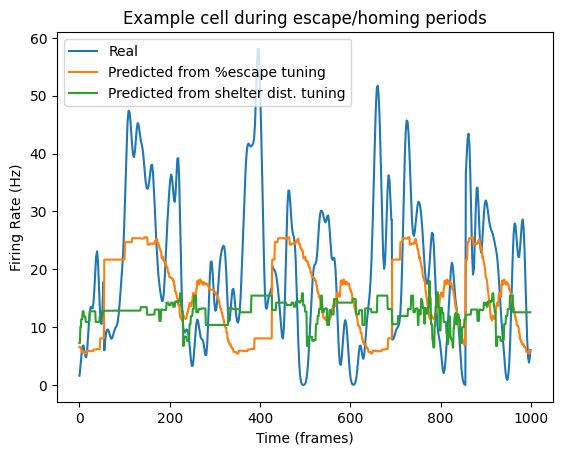

In [114]:
"""Plot a portion of the real trace and the predictions made using the tuning to % escape and dist to shelter in exploration"""
cond = 0
goodones = np.where(np.logical_and(exp_sig_cells[:,cond], sig_cells[:,cond]))[0]
idx = 1
plt.plot(escape_matrix[goodones[idx],10000:11000], label = 'Real')
plt.plot(predicted_matrix[goodones[idx],10000:11000], label = r'Predicted from %escape tuning')
plt.plot(exp_predicted_matrix[goodones[idx],10000:11000], label = 'Predicted from shelter dist. tuning')
plt.xlabel('Time (frames)')
plt.ylabel('Firing Rate (Hz)')
plt.legend()
plt.title('Example cell during escape/homing periods')

Text(0.5, 1.0, 'Example cell during escape/homing periods')

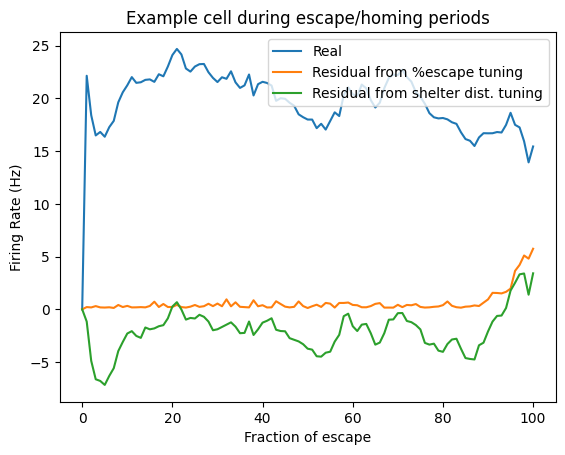

In [112]:
"""Plot the tuning to % escape from the real data and the predictions made using the tuning to % escape and dist to shelter in exploration"""
idx = 9
cond = 1
goodones = np.where(np.logical_and(exp_sig_cells[:,cond], sig_cells[:,cond]))[0]
plt.plot(fr_full[cond,goodones[idx],:], label = 'Real')
plt.plot(fr_full_res[cond,goodones[idx],:], label = r'Residual from %escape tuning')
plt.plot(fr_full_exp[cond,goodones[idx],:], label = 'Residual from shelter dist. tuning')
plt.ylabel('Firing Rate (Hz)')
plt.xlabel('Fraction of escape')
plt.legend(loc = 'upper right')
plt.title('Example cell during escape/homing periods')